# 2.1 Bluesky — Exploratory Data Analysis

**Pipeline:**  
Bronze → language filter (English only) → text cleaning → buzz labels → **Silver** (`bluesky_clean.parquet`)

Downstream notebooks: network (2.2) · textual (2.3) · NLP (2.4) · sentiment (2.5)

In [17]:
import sys, os
from pathlib import Path
sys.path.insert(0, os.path.join(os.path.abspath("."), "..", ".."))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from house_style import *
from Functions.text_preprocessing import apply_text_cleaning
from Functions.buzz_column import add_buzz_labels

apply_style()

BRONZE     = Path("../../Data/1_Bronze/Bluesky/bsky_US_2024_raw.csv")
SILVER_DIR = Path("../../Data/2_Silver/Bluesky")
SILVER_OUT = SILVER_DIR / "bluesky_clean.parquet"

df_bronze = pd.read_csv(BRONZE)
df_bronze["timestamp"] = pd.to_datetime(df_bronze["timestamp"], format='ISO8601', utc=True)
print(f"Loaded {len(df_bronze):,} rows x {df_bronze.shape[1]} columns")
df_bronze.head(3)

Loaded 32,862 rows x 13 columns


,uri,author,display,text,timestamp,likes,reposts,replies,mentions,is_reply,post_type,query,parent_uri
0,at://did:plc:taylv7omre5pg7arsuidtwg4/app.bsky...,outrowes.bsky.social,Wes,Os Swing States são os estados americanos onde...,2024-11-04 23:53:52.367000+00:00,1,1,0,[],False,post,#USElection2024,NaN
1,at://did:plc:lpqouffbl3gbah3r23vh7odp/app.bsky...,runhudi.bsky.social,Yehuda M.,Canadian election prediction: Americans will g...,2024-11-04 23:44:15.319000+00:00,0,0,1,[],False,post,#USElection2024,NaN
2,at://did:plc:3ixumkojw3dpsfhdyjodfxmk/app.bsky...,manabouttown.bsky.social,NaN,Why are swinger states so important in the #US...,2024-11-04 23:35:21.961000+00:00,0,0,0,[],False,post,#USElection2024,NaN


## 1. Bronze — raw data structure

In [18]:
df_bronze.head(5)

,uri,author,display,text,timestamp,likes,reposts,replies,mentions,is_reply,post_type,query,parent_uri
0,at://did:plc:taylv7omre5pg7arsuidtwg4/app.bsky...,outrowes.bsky.social,Wes,Os Swing States são os estados americanos onde...,2024-11-04 23:53:52.367000+00:00,1,1,0,[],False,post,#USElection2024,NaN
1,at://did:plc:lpqouffbl3gbah3r23vh7odp/app.bsky...,runhudi.bsky.social,Yehuda M.,Canadian election prediction: Americans will g...,2024-11-04 23:44:15.319000+00:00,0,0,1,[],False,post,#USElection2024,NaN
2,at://did:plc:3ixumkojw3dpsfhdyjodfxmk/app.bsky...,manabouttown.bsky.social,NaN,Why are swinger states so important in the #US...,2024-11-04 23:35:21.961000+00:00,0,0,0,[],False,post,#USElection2024,NaN
3,at://did:plc:pebmhdoqw45rp5bpu53myfoc/app.bsky...,justdev1.bsky.social,That Dev Guy,If Joe Biden winning felt like Return of the J...,2024-11-04 23:23:51.647000+00:00,0,0,0,[],False,post,#USElection2024,NaN
4,at://did:plc:bj6epztbrubmkloj4ethecvy/app.bsky...,alexverbeek.bsky.social,Alexander Verbeek,Will the U.S. Presidential Elections be a Turn...,2024-11-04 22:48:56.805000+00:00,3,1,1,[],False,post,#USElection2024,NaN


In [19]:
df_bronze.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32862 entries, 0 to 32861
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype              
---  ------      --------------  -----              
 0   uri         32862 non-null  object             
 1   author      32862 non-null  object             
 2   display     31610 non-null  object             
 3   text        32862 non-null  object             
 4   timestamp   32862 non-null  datetime64[ns, UTC]
 5   likes       32862 non-null  int64              
 6   reposts     32862 non-null  int64              
 7   replies     32862 non-null  int64              
 8   mentions    32862 non-null  object             
 9   is_reply    32862 non-null  bool               
 10  post_type   32862 non-null  object             
 11  query       32862 non-null  object             
 12  parent_uri  8051 non-null   object             
dtypes: bool(1), datetime64[ns, UTC](1), int64(3), object(8)
memory usage: 3.0+ MB


In [20]:
df_bronze.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
uri,32862,32862,at://did:plc:taylv7omre5pg7arsuidtwg4/app.bsky...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
author,32862,7188,antifapatriot.bsky.social,1581,NaN,NaN,NaN,NaN,NaN,NaN,NaN
display,31610,6791,america.is.not.free,1581,NaN,NaN,NaN,NaN,NaN,NaN,NaN
text,32862,31613,#Trump #Memeries #PastElections,79,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timestamp,32862,NaN,NaN,NaN,2024-09-28 09:05:28.227918592+00:00,2024-07-05 03:04:25.279000+00:00,2024-08-31 00:01:45.249834496+00:00,2024-10-08 13:26:48.188000256+00:00,2024-10-26 19:26:19.839000064+00:00,2026-01-19 01:45:26.080000+00:00,NaN
likes,32862.0,NaN,NaN,NaN,3.292009,0.0,0.0,1.0,2.0,3386.0,31.895009
reposts,32862.0,NaN,NaN,NaN,0.842219,0.0,0.0,0.0,0.0,2394.0,14.340776
replies,32862.0,NaN,NaN,NaN,0.302081,0.0,0.0,0.0,0.0,53.0,0.908562
mentions,32862,1115,[],30417,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_reply,32862,2,False,22469,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Text preprocessing → Buzz labels → Silver

In [21]:
df = apply_text_cleaning(df_bronze, text_col='text', filter_english=True)
df = add_buzz_labels(df, text_col='text_clean')

SILVER_DIR.mkdir(parents=True, exist_ok=True)
df.to_csv(SILVER_DIR / "bluesky_clean.csv", index=False)

print(f"Saved: {df.shape[0]:,} rows x {df.shape[1]} cols")

Detecting language for 32,862 rows (this may take a moment)...
✓ Language filter: kept 26,949 English rows (dropped 5,913 non-English, 18.0%)
✓ Cleaned 'text' → 'text_clean'
  Rows       : 26,949
  Avg words  : 14.5
  Empty texts: 109

                                          text_clean  word_count
0  canadian election prediction americans polls d...          24
1  swinger states important uselection really man...           8
2  joe biden winning felt like return jedi end el...          16
✓ Buzz labels added -> 'candidate'
  Rows     : 26,949
  TrumpBuzz           : 11,058  (41.0%)
  ElectionBuzz        : 8,153  (30.3%)
  HarrisBuzz          : 7,738  (28.7%)

Saved: 26,949 rows x 18 cols


## 3. Exploratory Analysis

All analyses below run on the Silver data: English only, cleaned, labelled.

In [22]:
df[['text', 'text_clean', 'word_count', 'candidate']].head(5)

,text,text_clean,word_count,candidate
0,Canadian election prediction: Americans will g...,canadian election prediction americans polls d...,24,TrumpBuzz
1,Why are swinger states so important in the #US...,swinger states important uselection really man...,8,ElectionBuzz
2,If Joe Biden winning felt like Return of the J...,joe biden winning felt like return jedi end el...,16,HarrisBuzz
3,Will the U.S. Presidential Elections be a Turn...,presidential elections turning point history t...,9,ElectionBuzz
4,Dear American voters! As a foreigner living in...,dear american voters foreigner living finland ...,24,HarrisBuzz


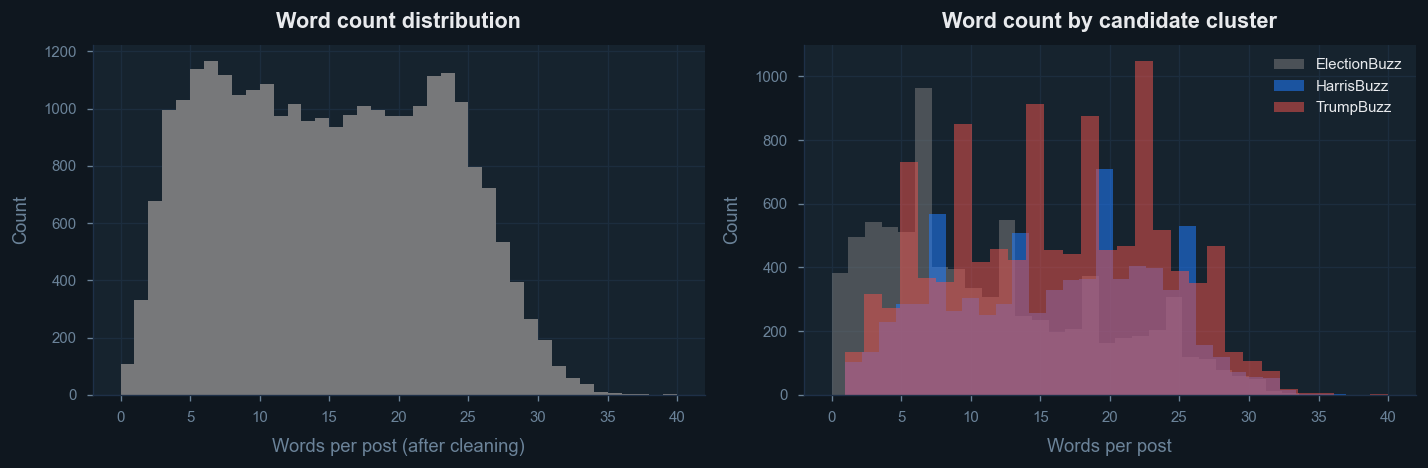

                count  mean  std  min   25%   50%   75%   max
candidate                                                    
ElectionBuzz   8153.0  11.1  7.8  0.0   5.0   9.0  17.0  36.0
HarrisBuzz     7738.0  16.0  7.4  1.0  10.0  17.0  22.0  37.0
TrumpBuzz     11058.0  16.0  7.5  1.0  10.0  16.0  22.0  40.0


In [23]:
COLORS = {"TrumpBuzz": REPUBLICAN, "HarrisBuzz": DEMOCRAT, "ElectionBuzz": NEUTRAL}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(df['word_count'], bins=40, color=NEUTRAL, edgecolor='none')
ax.set_xlabel("Words per post (after cleaning)", color=TEXT_MUTED)
ax.set_ylabel("Count", color=TEXT_MUTED)
ax.set_title("Word count distribution", color=TEXT_PRIMARY, pad=10)

ax = axes[1]
for cand, grp in df.groupby("candidate"):
    ax.hist(grp['word_count'], bins=30, alpha=0.55, label=cand,
            color=COLORS.get(cand, NEUTRAL))
ax.set_xlabel("Words per post", color=TEXT_MUTED)
ax.set_ylabel("Count", color=TEXT_MUTED)
ax.set_title("Word count by candidate cluster", color=TEXT_PRIMARY, pad=10)
ax.legend(frameon=False, labelcolor=TEXT_PRIMARY)

plt.tight_layout()
plt.show()

print(df.groupby('candidate')['word_count'].describe().round(1))

In [24]:
empty = (df['word_count'] == 0).sum()
print(f"Empty posts after cleaning : {empty:,} ({empty/len(df)*100:.1f}%)")
print(f"Average word count         : {df['word_count'].mean():.1f}")
print(f"Median word count          : {df['word_count'].median():.0f}")

Empty posts after cleaning : 109 (0.4%)
Average word count         : 14.5
Median word count          : 14


### Key counts per candidate

In [25]:
summary = pd.DataFrame({
    "posts"          : df.groupby("candidate").size(),
    "unique_authors" : df.groupby("candidate")["author"].nunique(),
    "avg_likes"      : df.groupby("candidate")["likes"].mean().round(2),
    "avg_reposts"    : df.groupby("candidate")["reposts"].mean().round(2),
    "pct_reply"      : (df.groupby("candidate")["is_reply"].mean() * 100).round(1),
})
summary

,posts,unique_authors,avg_likes,avg_reposts,pct_reply
candidate,,,,,
ElectionBuzz,8153,3294,2.72,0.75,57.1
HarrisBuzz,7738,1923,5.06,1.06,12.8
TrumpBuzz,11058,1983,2.44,0.82,17.0


### Daily post volume

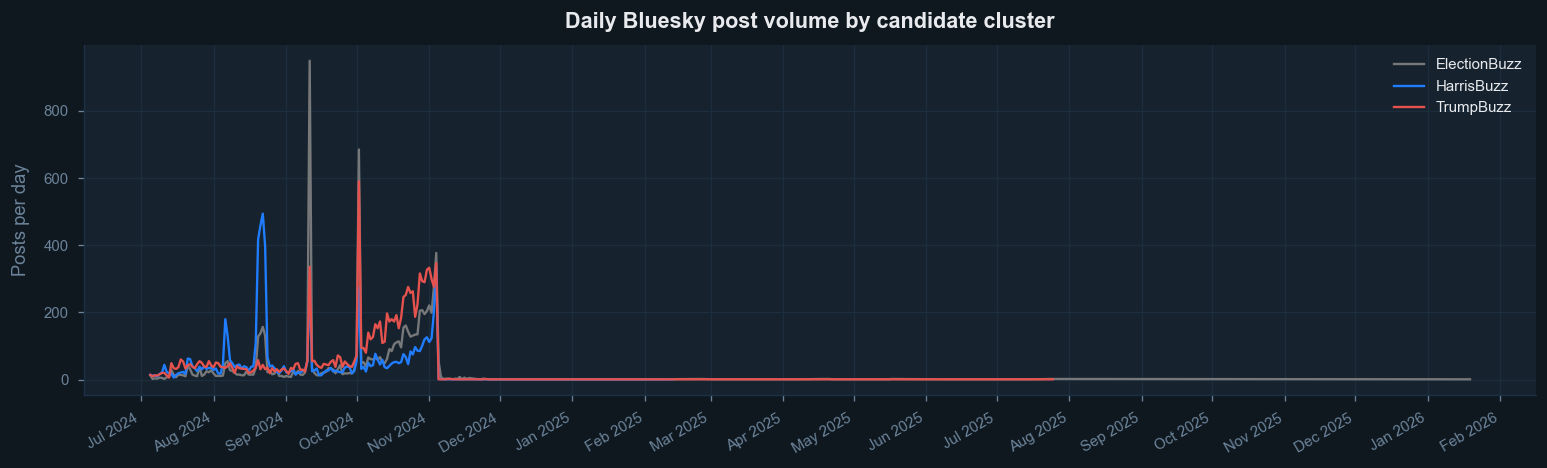

In [26]:
df["date"] = df["timestamp"].dt.normalize()

daily = df.groupby(["date", "candidate"]).size().reset_index(name="posts")

fig, ax = plt.subplots(figsize=(13, 4))
for cand, grp in daily.groupby("candidate"):
    ax.plot(grp["date"], grp["posts"], label=cand,
            color=COLORS.get(cand, NEUTRAL), linewidth=1.4)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.set_ylabel("Posts per day", color=TEXT_MUTED)
ax.set_title("Daily Bluesky post volume by candidate cluster", color=TEXT_PRIMARY, pad=10)
ax.legend(frameon=False, labelcolor=TEXT_PRIMARY)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Like distribution (log scale)

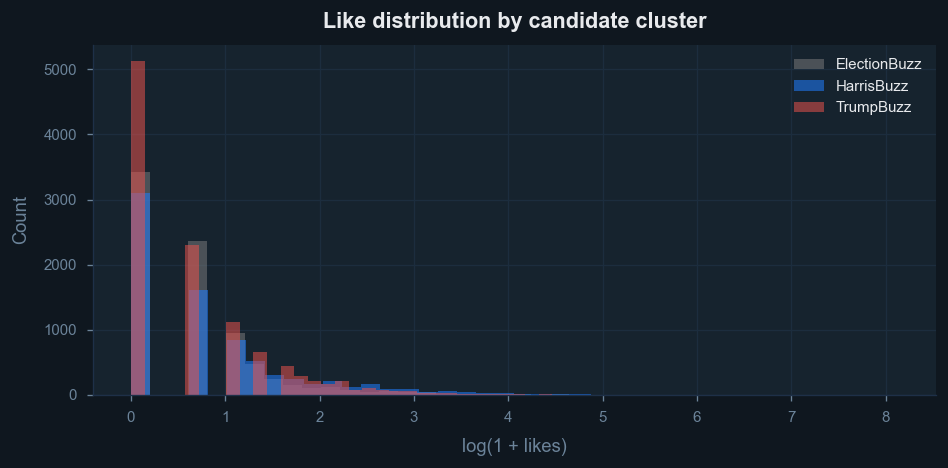

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))
for cand, grp in df.groupby("candidate"):
    ax.hist(np.log1p(grp["likes"]), bins=40, alpha=0.55,
            label=cand, color=COLORS.get(cand, NEUTRAL))
ax.set_xlabel("log(1 + likes)", color=TEXT_MUTED)
ax.set_ylabel("Count", color=TEXT_MUTED)
ax.set_title("Like distribution by candidate cluster", color=TEXT_PRIMARY, pad=10)
ax.legend(frameon=False, labelcolor=TEXT_PRIMARY)
plt.tight_layout()
plt.show()